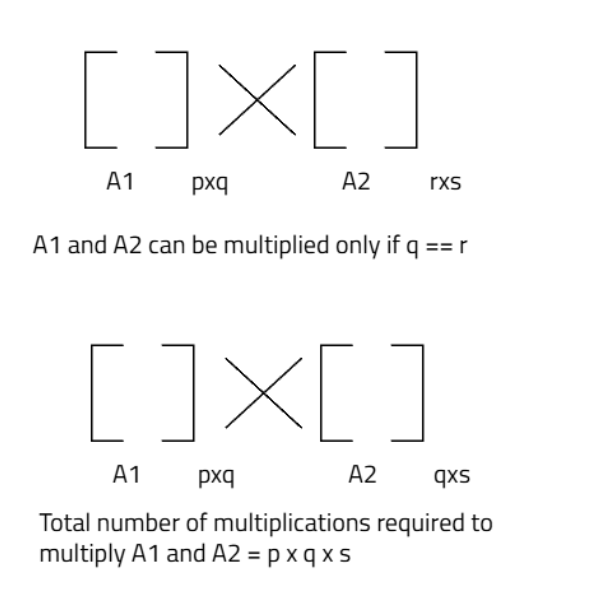

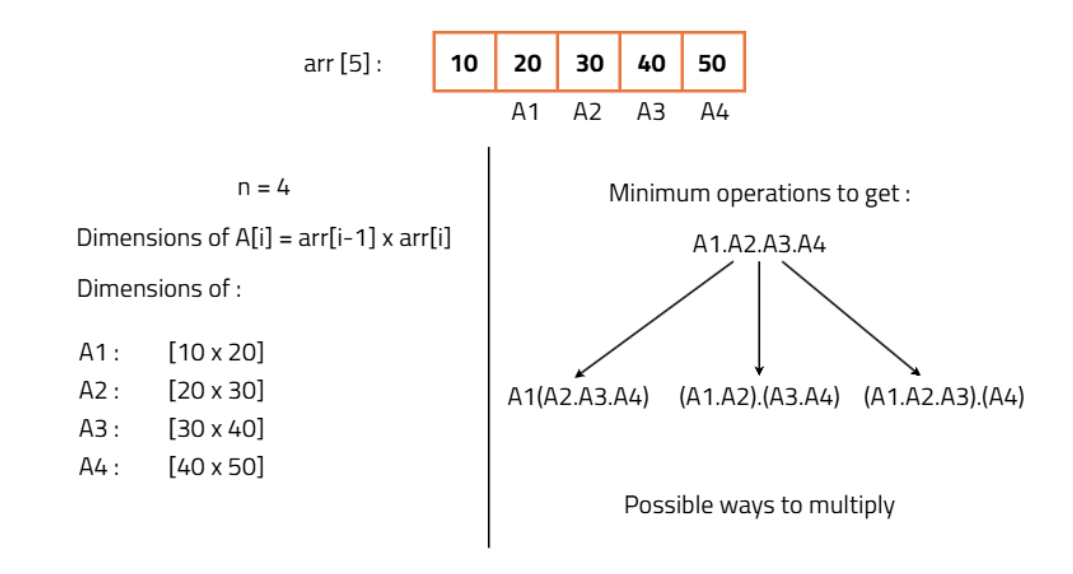

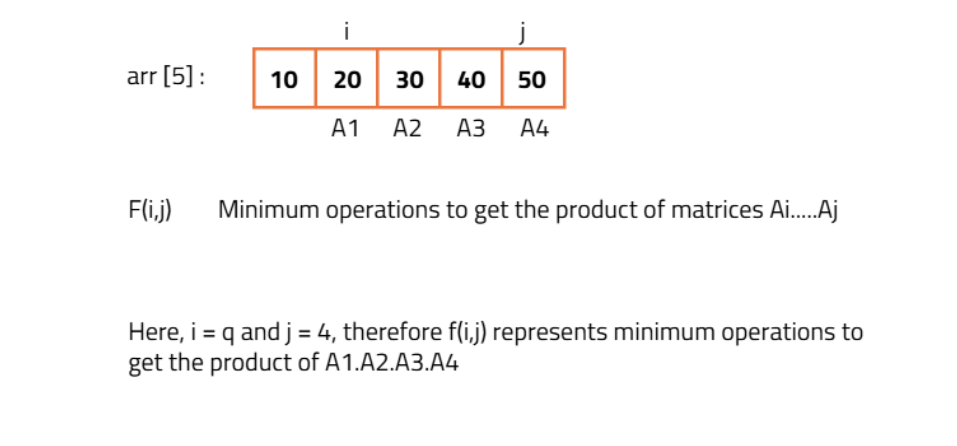

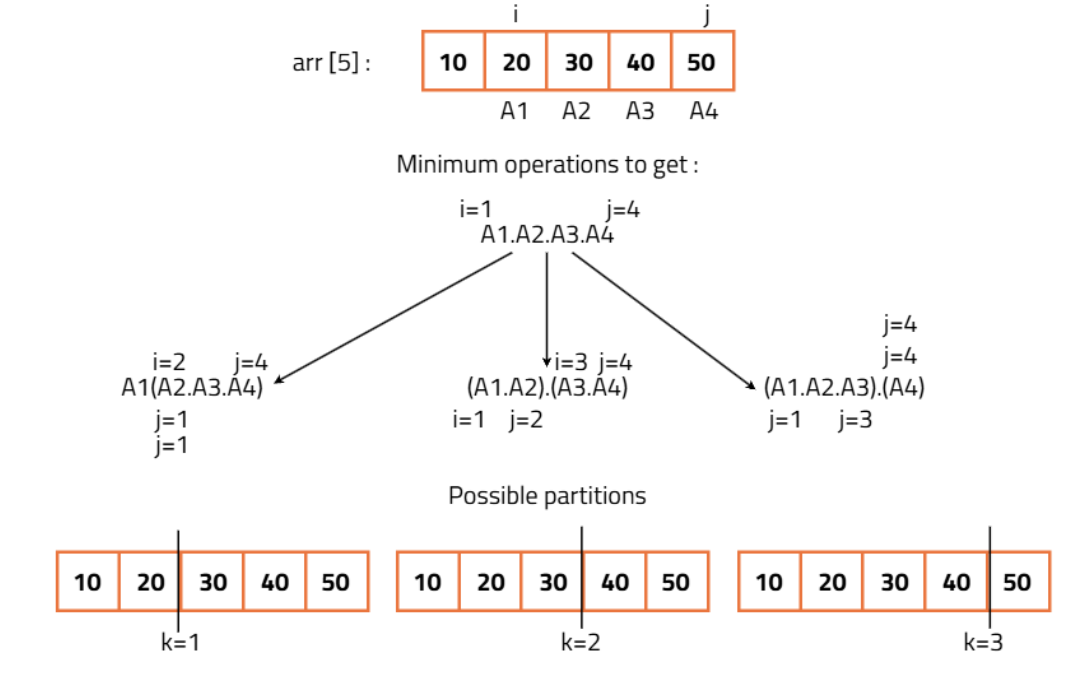

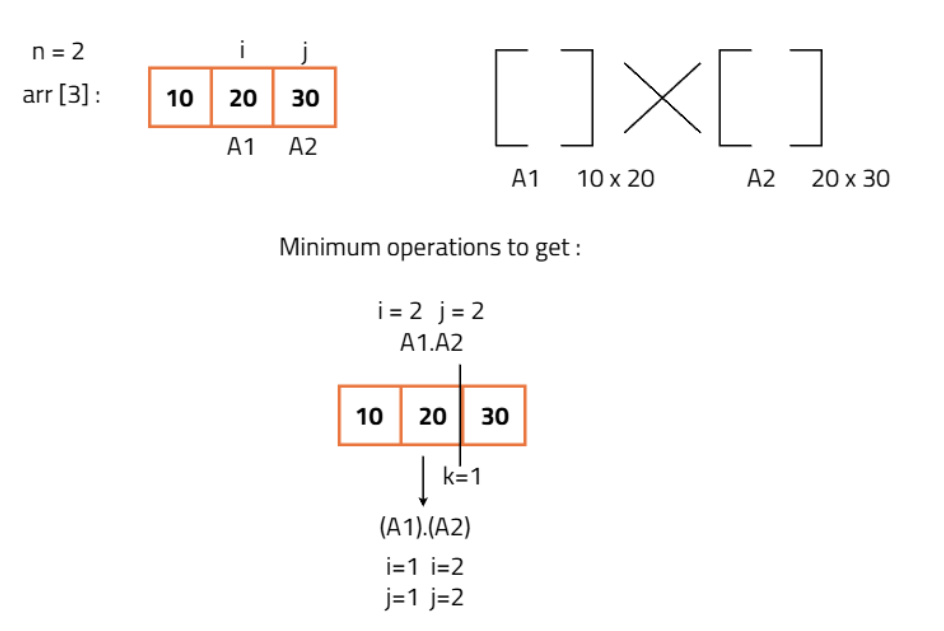

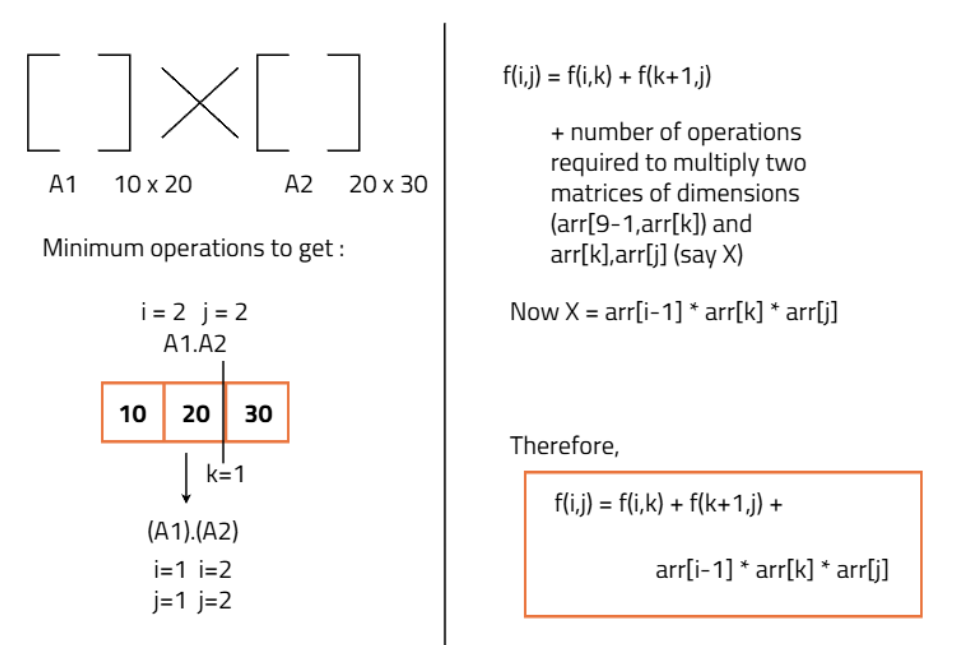

In [1]:
# Recursive Approch
def matrixChainOrder(arr,i,j):
    # Base case :- if only one matrix is present, no multiplication needed
    if i == j:
        return 0
    
    # Initialize minimum cost as very large
    min_cost = float('inf')

    # Try all possible partitions
    for k in range(i,j):
        # Cost of multiplying from i to k
        cost1 = matrixChainOrder(arr,i,k)

        # Cost of multiplying from k to j
        cost2 = matrixChainOrder(arr,k+1,j)

        # Cost of multiplying the two resulting matrices
        costMulti = arr[i-1] * arr[k] * arr[j]

        # total cost for this partition
        total = cost1 + cost2 + costMulti

        # Update minimum
        min_cost = min(min_cost,total)
    
    return min_cost

# Driver code
if __name__ == "__main__":
    arr = [40, 20, 30, 10, 30]
    n = len(arr)
    print("Minimum number of multiplications is:",
          matrixChainOrder(arr, 1, n - 1))



Minimum number of multiplications is: 26000


In [ ]:
#                          M(1,4)
#                          = 26000
#                             |
#              ┌──────────────┼──────────────┐
#              ↓              ↓              ↓
#            k=1             k=2            k=3
#              ↓              ↓              ↓
#           36000           69000          26000
#              |              |              |
#           M(2,4)          M(1,2)         M(1,3)
#           =12000          =24000         =14000
#              |              |              |
#        ┌─────┴─────┐        |        ┌────┴────┐
#        ↓           ↓        |        ↓         ↓
#     k=2           k=3       |      k=1       k=2
#     27000         12000     |      14000     36000
#        |             |      |        |          |
#        |             |      |        |          |
#    M(3,4)         M(2,3)   ...    M(2,3)     M(1,2)
#     9000            6000           6000       24000
#        |             |               |           |
#        ↓             ↓               ↓           ↓
#       0+0+9000      0+0+6000       ...       0+0+24000

In [3]:
class Solution:
    # Recursive function with memoization
    def solve(self, arr, i, j, dp):
        # Base case: only one matrix, no multiplication
        if i == j:
            return 0

        # If already computed, return from dp
        if dp[i][j] != -1:
            return dp[i][j]

        min_cost = float("inf")

        # Try every partition
        for k in range(i, j):
            cost1 = self.solve(arr, i, k, dp)
            cost2 = self.solve(arr, k + 1, j, dp)
            costMultiply = arr[i - 1] * arr[k] * arr[j]
            total = cost1 + cost2 + costMultiply
            min_cost = min(min_cost, total)

        dp[i][j] = min_cost
        return dp[i][j]

    def matrixChainOrder(self, arr):
        n = len(arr)
        dp = [[-1] * n for _ in range(n)]
        return self.solve(arr, 1, n - 1, dp)


# Driver code
if __name__ == "__main__":
    sol = Solution()
    arr = [40, 20, 30, 10, 30]
    print("Minimum number of multiplications is:",
          sol.matrixChainOrder(arr))


Minimum number of multiplications is: 26000
